# loading the dataset

In [1]:
import pandas as pd
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding='ISO-8859-1')

In [2]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [3]:
# Display the first few rows to verify the data load
print("=== First 5 Rows of Supply Chain Dataset ===")
print(df.head())

=== First 5 Rows of Supply Chain Dataset ===
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1  

In [4]:
#checking the  types of the data

In [5]:
# Check and print data types for each column
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        floa

# missing values finding

In [6]:
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Missing Values Count ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market    

In [7]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')

features_with_missing_values(df)

Percentage of Total Missing Values is  3.51 %
Missing Value Estimation :
The Feature  Customer Lname  has 8 missing values
The Feature  Customer Zipcode  has 3 missing values
The Feature  Order Zipcode  has 155679 missing values
The Feature  Product Description  has 180519 missing values


# description of the dataset

In [8]:
print("\n=== Descriptive Statistics (Categorical Columns) ===")
print(df.describe(include=['O']))


=== Descriptive Statistics (Categorical Columns) ===
          Type Delivery Status Category Name Customer City Customer Country  \
count   180519          180519        180519        180519           180519   
unique       4               4            50           563                2   
top      DEBIT   Late delivery        Cleats        Caguas          EE. UU.   
freq     69295           98977         24551         66770           111146   

       Customer Email Customer Fname Customer Lname Customer Password  \
count          180519         180519         180511            180519   
unique              1            782           1109                 1   
top         XXXXXXXXX           Mary          Smith         XXXXXXXXX   
freq           180519          65150          64104            180519   

       Customer Segment  ...     Order City   Order Country  \
count            180519  ...         180519          180519   
unique                3  ...           3597             16

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

# Size of the dataset

In [10]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


# unique values

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Delivery Status
Number of unique values: 4

Column: Category Name
Number of unique values: 50

Column: Customer City
Number of unique values: 563

Column: Customer Country
Number of unique values: 2

Column: Customer Email
Number of unique values: 1

Column: Customer Fname
Number of unique values: 782

Column: Customer Lname
Number of unique values: 1110

Column: Customer Password
Number of unique values: 1

Column: Customer Segment
Number of unique values: 3

Column: Customer State
Number of unique values: 46

Column: Customer Street
Number of unique values: 7458

Column: Department Name
Number of unique values: 11

Column: Market
Number of unique values: 5

Column: Order City
Number of unique values: 3597

Column: Order Country
Number of unique values: 164

Column: order date (DateOrders)
Number of unique values: 65752

Column: Order Region
Number of unique values: 23

Column: Order State
Number of unique values: 1089

Column: Order S

# preprocessing

In [12]:
modeling_columns = ['Type',
                  'Days for shipping (real)',
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Latitude',
                  'Longitude',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Order Status',
                  'Shipping Mode',
                  'Late_delivery_risk']

In [13]:
len(modeling_columns)

14

In [14]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [15]:
columns_to_drop = [col for col in df.columns if col not in modeling_columns]

In [16]:
len(columns_to_drop)

39

In [17]:
df1=drop_columns(df,columns_to_drop)

39 columns dropped successfully. Number of columns remaining: 14


In [18]:
print(f"Dataset rows: {df1.shape[0]}")
print(f"Dataset columns: {df1.shape[1]}")

Dataset rows: 180519
Dataset columns: 14


In [19]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [20]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total',
       'Order Profit Per Order', 'Order Status', 'Shipping Mode'],
      dtype='object')

In [21]:
# check null values
df1.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
Latitude                         0
Longitude                        0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Total                 0
Order Profit Per Order           0
Order Status                     0
Shipping Mode                    0
dtype: int64

In [22]:
#analyze categorical columns
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Order Status
Number of unique values: 9

Column: Shipping Mode
Number of unique values: 4


In [23]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [24]:
#analyze categorical columns
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Order Status
Number of unique values: 9

Column: Shipping Mode
Number of unique values: 4


# count the number of duplicate rows

In [25]:
df1.duplicated().sum()

4

In [26]:
df1=df1.drop_duplicates()

In [27]:
#df1 = df1.fillna(0) for handling missing values

In [28]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [29]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total',
       'Order Profit Per Order', 'Order Status', 'Shipping Mode'],
      dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Type','Order Status', 'Shipping Mode']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

/home/sanjeev/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [31]:
df1.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3


In [32]:
df1.shape

(180515, 14)

# Separate Features and Target

In [33]:
X = df1.drop(columns=['Late_delivery_risk'])  # features
y = df1['Late_delivery_risk']                 # target

In [34]:
X

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [35]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180515, dtype: int64

# Normalize Feature Values

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
X_scaled

array([[0.33333333, 0.5       , 1.        , ..., 0.84179973, 0.25      ,
        1.        ],
       [1.        , 0.83333333, 1.        , ..., 0.77618291, 0.625     ,
        1.        ],
       [0.        , 0.66666667, 1.        , ..., 0.77643548, 0.125     ,
        1.        ],
       ...,
       [1.        , 0.83333333, 1.        , ..., 0.85141263, 0.625     ,
        1.        ],
       [0.66666667, 0.5       , 1.        , ..., 0.86011167, 0.75      ,
        1.        ],
       [0.66666667, 0.66666667, 1.        , ..., 0.85678012, 0.75      ,
        1.        ]])

In [38]:
X_scaled.shape

(180515, 13)

# converting into 3D shape because for LSTM we need to convert the data

In [39]:
import numpy as np
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [40]:
X_lstm.shape   #(samples, time steps, features)

(180515, 1, 13)

In [41]:
X.shape[1]

13

In [42]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Input

# Define LSTM Model
input_layer = Input(shape=(1, X.shape[1]))
lstm_layer = LSTM(64, return_sequences=False)(input_layer)  # Output: (batch_size, 64) hidden size of the LSTM layer.
model = Model(inputs=input_layer, outputs=lstm_layer)

In [43]:
model

In [44]:
X_features = model.predict(X_lstm)
print(X_features.shape)  # (num_samples, 64)

(180515, 64)


In [45]:
y.shape

(180515,)

In [46]:
np.save("simple_LSTM_softmax_rf_13fetures_64_64",X_features)

In [47]:
set(y)

{0, 1}

# softmax

In [48]:
from tensorflow.keras.utils import to_categorical

y_categorical = to_categorical(y)  # This converts [0,1,0,...] to [[1,0],[0,1],...]

In [49]:
y_categorical[0] ,y_categorical.shape

(array([1., 0.], dtype=float32), (180515, 2))

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_categorical, test_size=0.2, random_state=42)

In [51]:
X_train.shape, X_test.shape , y_train.shape , y_test.shape

((144412, 64), (36103, 64), (144412, 2), (36103, 2))

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_softmax = Sequential()
model_softmax.add(Dense(64, input_shape=(64,), activation='relu'))  # You can tune this
model_softmax.add(Dropout(0.3))
model_softmax.add(Dense(y_categorical.shape[1], activation='softmax'))  # Output layer

In [53]:
model_softmax.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model_softmax.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
903/903 [==============================] - 3s 3ms/step - loss: 0.2904 - accuracy: 0.9193 - val_loss: 0.1389 - val_accuracy: 0.9782
Epoch 2/20
903/903 [==============================] - 2s 3ms/step - loss: 0.1107 - accuracy: 0.9808 - val_loss: 0.0968 - val_accuracy: 0.9817
Epoch 3/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0835 - accuracy: 0.9845 - val_loss: 0.0775 - val_accuracy: 0.9841
Epoch 4/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0685 - accuracy: 0.9857 - val_loss: 0.0641 - val_accuracy: 0.9842
Epoch 5/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0572 - accuracy: 0.9862 - val_loss: 0.0531 - val_accuracy: 0.9849
Epoch 6/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0495 - accuracy: 0.9866 - val_loss: 0.0458 - val_accuracy: 0.9852
Epoch 7/20
903/903 [==============================] - 2s 3ms/step - loss: 0.0430 - accuracy: 0.9871 - val_loss: 0.0390 - val_accuracy: 0.9860
Epoch 

In [54]:
loss, accuracy = model_softmax.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

1129/1129 [==============================] - 1s 1ms/step - loss: 0.0072 - accuracy: 0.9972
Test Accuracy: 99.72%


In [55]:
training_accuracy = history.history['accuracy'][-1]  # Accuracy from the last epoch
print(f"Training Accuracy: {training_accuracy * 100:.2f}%")

Training Accuracy: 99.75%


In [56]:
num_classes = len(np.unique(y))  # ✅ number of unique class labels
num_classes

2

In [62]:
# Get predicted probabilities
y_pred_probs = model_softmax.predict(X_test)

# Convert probabilities to predicted class labels
predicted_labels = y_pred_probs.argmax(axis=1)


In [63]:
true_labels = y_test.argmax(axis=1)


In [64]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 99.72%


In [65]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
# Convert y_test from one-hot to integer labels
y_test_labels = np.argmax(y_test, axis=1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# If you want original labels (like 0 or 1), you can decode them
y_test_decoded = label_encoder.inverse_transform(y_test_labels)
final_predictions_decoded = label_encoder.inverse_transform(predicted_labels)

# Now compare
print("Classification Report:\n")
print(classification_report(y_test_decoded, final_predictions_decoded))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     16387
           1       0.99      1.00      1.00     19716

    accuracy                           1.00     36103
   macro avg       1.00      1.00      1.00     36103
weighted avg       1.00      1.00      1.00     36103



In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test_labels, predicted_labels)

#plt.figure(figsize=(8,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

<Figure size 640x480 with 2 Axes>

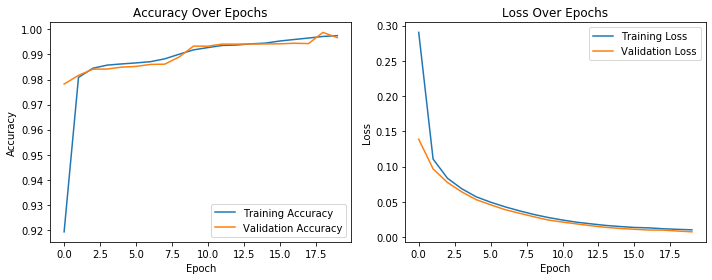

In [67]:
# Accuracy Plot
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')  # if used
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')  # if used
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


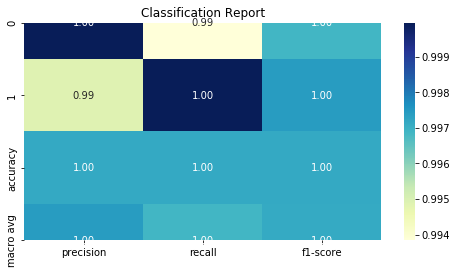

In [68]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test_labels, predicted_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

In [69]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test_labels, predicted_labels)
report=classification_report(y_test_labels, predicted_labels)
mcc=matthews_corrcoef(y_test_labels, predicted_labels)
kappa=cohen_kappa_score(y_test_labels, predicted_labels)
precision=precision_score(y_test_labels, predicted_labels)
recall=recall_score(y_test_labels, predicted_labels)
f1=f1_score(y_test_labels, predicted_labels)

In [70]:
tn,fp,fn,tp=cm.ravel()

In [71]:
tn,fp,fn,tp

(16286, 101, 1, 19715)

In [72]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [73]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9943136435927544,
 0.9942981077626737,
 0.9949031085991118,
 0.9999492797727734,
 0.9974198117980371,
 0.006163422224934399,
 5.0720227226617976e-05)

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
#from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

In [104]:
def create_model(optimizer='adam', dropout_rate=0.3, hidden_units=64):
    model = Sequential()
    model.add(Dense(hidden_units, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(y_categorical.shape[1], activation='softmax'))
    
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [105]:
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'dropout_rate': [0.2, 0.3, 0.5],
    'hidden_units': [32, 64, 128],
    'batch_size': [32, 64],
    'epochs': [10]  # You can increase this
}


In [106]:
import itertools
import numpy as np

best_acc = 0
best_params = None
results = []

# Iterate over all combinations
for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    
    print(f"Training with: {params}")
    model = create_model(optimizer=params['optimizer'],
                         dropout_rate=params['dropout_rate'],
                         hidden_units=params['hidden_units'])
    
    history = model.fit(X_train, y_train, 
                        epochs=params['epochs'],
                        batch_size=params['batch_size'],
                        validation_split=0.2,
                        verbose=0)
    
    val_acc = max(history.history['val_accuracy'])
    results.append((params, val_acc))

    if val_acc > best_acc:
        best_acc = val_acc
        best_params = params

print("\n✅ Best Params:")
print(best_params)
print(f"✅ Best Validation Accuracy: {best_acc * 100:.2f}%")


Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 32, 'batch_size': 32, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 32, 'batch_size': 64, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 64, 'batch_size': 32, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 64, 'batch_size': 64, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 128, 'batch_size': 32, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 128, 'batch_size': 64, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.3, 'hidden_units': 32, 'batch_size': 32, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.3, 'hidden_units': 32, 'batch_size': 64, 'epochs': 10}
Training with: {'optimizer': 'adam', 'dropout_rate': 0.3, 'hidden_units': 64, 'batch_size': 32, 'epochs': 10}
Training

In [110]:
results

[({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 32,
   'batch_size': 32,
   'epochs': 10},
  0.9941487908363342),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 32,
   'batch_size': 64,
   'epochs': 10},
  0.9941487908363342),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 64,
   'batch_size': 32,
   'epochs': 10},
  0.9957067966461182),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 64,
   'batch_size': 64,
   'epochs': 10},
  0.9947027564048767),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 128,
   'batch_size': 32,
   'epochs': 10},
  0.9997576475143433),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 128,
   'batch_size': 64,
   'epochs': 10},
  0.9997230172157288),
 ({'optimizer': 'adam',
   'dropout_rate': 0.3,
   'hidden_units': 32,
   'batch_size': 32,
   'epochs': 10},
  0.99407958984375),
 ({'optimizer': 'adam',
   'dropout_rate': 0.3,
   'hidden_units': 32

In [113]:
accuracies = [acc*100 for _, acc in results]
g=[print(i) for i in accuracies]


99.41487908363342
99.41487908363342
99.57067966461182
99.47027564048767
99.97576475143433
99.97230172157288
99.407958984375
98.7362802028656
99.72648024559021
99.4010329246521
99.96191263198853
99.446040391922
98.60125184059143
98.60125184059143
99.41487908363342
98.6393392086029
99.41487908363342
99.41487908363342
99.41487908363342
99.2313802242279
99.87189769744873
99.74033236503601
99.95845556259155
99.97576475143433
99.01672005653381
98.18578362464905
99.54644441604614
99.39064383506775
99.94460344314575
99.92383122444153
98.49392175674438
98.49392175674438
99.12058711051941
98.60125184059143
99.4910478591919
99.42526817321777


In [114]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
model_softmax = Sequential()
model_softmax.add(Dense(64, input_shape=(64,), activation='relu'))   # First hidden layer
model_softmax.add(Dropout(0.3))                                      # Dropout for regularization
model_softmax.add(Dense(y_categorical.shape[1], activation='softmax'))  # Output layer

# Compile the model
model_softmax.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # You can also monitor 'val_accuracy'
    patience=5,             # Stop if no improvement for 5 epochs
    restore_best_weights=True  # Roll back to best weights after stopping
)

# Train the model with early stopping
history = model_softmax.fit(
    X_train, y_train,
    epochs=100,             # Set high, but EarlyStopping will cut it early
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],  # 👈 Add the callback here
    verbose=1
)


Epoch 1/100
903/903 [==============================] - 3s 3ms/step - loss: 0.3200 - accuracy: 0.8968 - val_loss: 0.1566 - val_accuracy: 0.9770
Epoch 2/100
903/903 [==============================] - 3s 3ms/step - loss: 0.1261 - accuracy: 0.9794 - val_loss: 0.1092 - val_accuracy: 0.9815
Epoch 3/100
903/903 [==============================] - 3s 3ms/step - loss: 0.0966 - accuracy: 0.9830 - val_loss: 0.0920 - val_accuracy: 0.9817
Epoch 4/100
903/903 [==============================] - 3s 3ms/step - loss: 0.0830 - accuracy: 0.9844 - val_loss: 0.0792 - val_accuracy: 0.9839
Epoch 5/100
903/903 [==============================] - 3s 3ms/step - loss: 0.0718 - accuracy: 0.9852 - val_loss: 0.0680 - val_accuracy: 0.9842
Epoch 6/100
903/903 [==============================] - 3s 3ms/step - loss: 0.0628 - accuracy: 0.9853 - val_loss: 0.0587 - val_accuracy: 0.9842
Epoch 7/100
903/903 [==============================] - 3s 3ms/step - loss: 0.0555 - accuracy: 0.9857 - val_loss: 0.0533 - val_accuracy: 0.9842

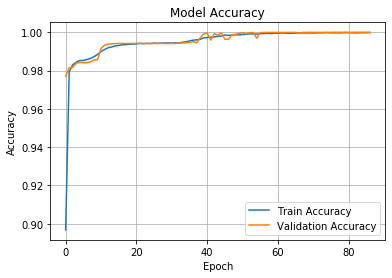

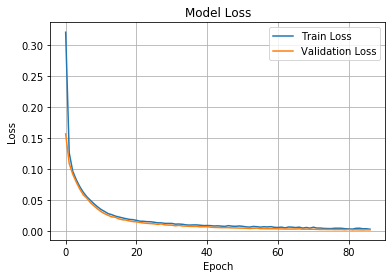

In [115]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop

def create_model(optimizer='adam', dropout_rate=0.2, hidden_units=64):
    model = Sequential()
    model.add(Dense(hidden_units, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(y_categorical.shape[1], activation='softmax'))  # For multiclass
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [127]:
import itertools
import numpy as np

best_acc = 0
best_params = None
results = []

# Iterate over all combinations
for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    
    print(f"Training with: {params}")
    model = create_model(optimizer=params['optimizer'],
                         dropout_rate=params['dropout_rate'],
                         hidden_units=params['hidden_units'])
    
    history = model.fit(X_train, y_train, 
                        epochs=params['epochs'],
                        batch_size=params['batch_size'],
                        validation_split=0.2,
                        verbose=0)
    
    val_acc = max(history.history['val_accuracy'])
    results.append((params, val_acc))

    if val_acc > best_acc:
        best_acc = val_acc
        best_params = params

print("\n✅ Best Params:")
print(best_params)
print(f"✅ Best Validation Accuracy: {best_acc * 100:.2f}%")


Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 32, 'batch_size': 32, 'epochs': 10}


KeyboardInterrupt: 

In [120]:
results

[({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 32,
   'batch_size': 32,
   'epochs': 10},
  0.9941487908363342),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 32,
   'batch_size': 64,
   'epochs': 10},
  0.9876397848129272),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 64,
   'batch_size': 32,
   'epochs': 10},
  0.9995845556259155),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 64,
   'batch_size': 64,
   'epochs': 10},
  0.9970570802688599),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 128,
   'batch_size': 32,
   'epochs': 10},
  0.9998269081115723),
 ({'optimizer': 'adam',
   'dropout_rate': 0.2,
   'hidden_units': 128,
   'batch_size': 64,
   'epochs': 10},
  0.9996537566184998),
 ({'optimizer': 'adam',
   'dropout_rate': 0.3,
   'hidden_units': 32,
   'batch_size': 32,
   'epochs': 10},
  0.9944257736206055),
 ({'optimizer': 'adam',
   'dropout_rate': 0.3,
   'hidden_units': 

In [121]:
accuracies = [acc*100 for _, acc in results]
g=[print(i) for i in accuracies]

99.41487908363342
98.76397848129272
99.95845556259155
99.70570802688599
99.98269081115723
99.96537566184998
99.44257736206055
99.13443922996521
99.41487908363342
99.42873120307922
99.98615384101868
99.446040391922
98.49392175674438
98.15808534622192
99.41487908363342
99.17598366737366
99.93767738342285
99.41834211349487
99.41487908363342
99.3490993976593
99.96191263198853
99.42526817321777
99.98615384101868
99.97576475143433
99.01672005653381
98.6912727355957
99.45642948150635
99.52913522720337
99.95152950286865
99.97230172157288
98.60125184059143
98.38313460350037
98.79167675971985
99.12405014038086
99.82689023017883
99.41487908363342


In [122]:
import pandas as pd

# Convert list of (params_dict, accuracy) to flat records
records = []
for params, acc in results:
    record = params.copy()
    record['val_accuracy'] = acc
    records.append(record)

# Create DataFrame
df = pd.DataFrame(records)

# Optional: Sort by highest accuracy
df = df.sort_values(by='val_accuracy', ascending=False).reset_index(drop=True)

# Display table
print(df)

# Save to CSV if needed
df.to_csv("slstm_14_grid_search_results.csv", index=False)


   optimizer  dropout_rate  hidden_units  batch_size  epochs  val_accuracy
0       adam           0.3           128          32      10      0.999862
1    rmsprop           0.2           128          32      10      0.999862
2       adam           0.2           128          32      10      0.999827
3    rmsprop           0.2           128          64      10      0.999758
4    rmsprop           0.3           128          64      10      0.999723
5       adam           0.2           128          64      10      0.999654
6    rmsprop           0.2            64          32      10      0.999619
7       adam           0.2            64          32      10      0.999585
8    rmsprop           0.3           128          32      10      0.999515
9       adam           0.5           128          32      10      0.999377
10   rmsprop           0.5           128          32      10      0.998269
11      adam           0.2            64          64      10      0.997057
12   rmsprop           0.

In [123]:
pivot = df.pivot_table(index=['optimizer', 'dropout_rate'], 
                       columns='hidden_units', 
                       values='val_accuracy')
print(pivot)

hidden_units                 32        64        128
optimizer dropout_rate                              
adam      0.2           0.990894  0.998321  0.999740
          0.3           0.992885  0.994218  0.997161
          0.5           0.983260  0.992954  0.996780
rmsprop   0.2           0.993820  0.996936  0.999810
          0.3           0.988540  0.994928  0.999619
          0.5           0.984922  0.989579  0.996209


In [124]:
pivot.to_csv("pivot_slstm_14_grid_results.csv")

In [128]:
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping
import itertools
import numpy as np
import pandas as pd

best_acc = 0
best_params = None
results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Iterate over all hyperparameter combinations
for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    print(f"🔄 Training with: {params}")
    
    fold_accuracies = []

    # Perform 5-fold CV
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = create_model(optimizer=params['optimizer'],
                             dropout_rate=params['dropout_rate'],
                             hidden_units=params['hidden_units'])

        history = model.fit(X_tr, y_tr,
                            validation_data=(X_val, y_val),
                            epochs=params['epochs'],
                            batch_size=params['batch_size'],
                            callbacks=[early_stop],
                            verbose=0)

        val_acc = max(history.history['val_accuracy'])  # Or use last epoch's accuracy
        fold_accuracies.append(val_acc)

    mean_acc = np.mean(fold_accuracies)
    results.append((params, mean_acc))
    print(f"✅ Mean Validation Accuracy: {mean_acc:.4f}\n")

    if mean_acc > best_acc:
        best_acc = mean_acc
        best_params = params

# Create a summary table
records = []
for params, acc in results:
    row = params.copy()
    row['val_accuracy'] = acc
    records.append(row)

df = pd.DataFrame(records)
df.to_csv("5fold_grid_search_results.csv", index=False)

# Create pivot table (optional)
pivot_df = df.pivot_table(index=['optimizer', 'dropout_rate'],
                          columns='hidden_units',
                          values='val_accuracy')

pivot_df.to_csv("5fold_grid_pivot.csv")

# Print best result
print("🏆 Best Parameters:")
print(best_params)
print(f"Best Cross-Validated Accuracy: {best_acc * 100:.2f}%")


🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 32, 'batch_size': 32, 'epochs': 10}
✅ Mean Validation Accuracy: 0.9943

🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 32, 'batch_size': 64, 'epochs': 10}
✅ Mean Validation Accuracy: 0.9945

🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 64, 'batch_size': 32, 'epochs': 10}
✅ Mean Validation Accuracy: 0.9976

🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 64, 'batch_size': 64, 'epochs': 10}
✅ Mean Validation Accuracy: 0.9957

🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 128, 'batch_size': 32, 'epochs': 10}
✅ Mean Validation Accuracy: 0.9999

🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.2, 'hidden_units': 128, 'batch_size': 64, 'epochs': 10}
✅ Mean Validation Accuracy: 0.9987

🔄 Training with: {'optimizer': 'adam', 'dropout_rate': 0.3, 'hidden_units': 32, 'batch_size': 32, 'epochs': 10